# Category Categorization based on Nutri-Score Distribution

Goal:
Identify food product categories that are well-suited for providing clear, helpful recommendations to guide consumers toward healthier choices.

## Challenges

- Product categories vary greatly in specificity and popularity (frequency of use or scans).
- Some categories are too broad or too niche, making it difficult to generate consistent or meaningful nutritional advice.
- We need to strike a balance between coverage (reaching many products) and clarity (providing strong, actionable recommendations).

## Approach

- Focus on popular products
  - Analyze only categories from products with a high number of scans. 
  - This ensures we're targeting the most relevant and frequently encountered product types.
- Filter by frequency
  - Retain only categories with at least 100 product occurrences.
  - This avoids overfitting to extremely specific or rarely used categories.
- Use Nutri-Score distribution as a signal
  - A category's internal distribution of Nutri-Scores (A to E) is used as a proxy for its nutritional homogeneity.
  - Homogeneous categories → clearer and more actionable advice.
  - Heterogeneous categories → less consistent, requiring more nuanced or conditional guidance.

## Heuristics

- **Not applicable** categories contain products where Nutri-Score is not defined or not relevant (e.g., alcohol, baby food, dietary supplements). These require meaningful, category-specific recommendations that go beyond standard Nutri-Score logic.
- **Great** categories have a single dominant Nutri-Score (A–E), allowing for clear, consistent recommendations.
- **Good** categories have two dominant Nutri-Scores (A+B, B+C, C+D, or D+E), still allowing for relatively clear guidance.
- **Fair** categories have three dominant Nutri-Scores (A+B+C, B+C+D, or C+D+E), which may require more nuanced advice.
- **Poor** categories have fragmented or contradictory Nutri-Score distributions (e.g., A+D or A+C+E), making consistent recommendations difficult.
- **Generic** categories show an even distribution across four or all five Nutri-Scores — too broad for meaningful category-level advice, requiring case-by-case recommendations.
- Categories skewed toward D or E Nutri-Scores are particularly useful for highlighting the need for healthier alternatives and making strong recommendations.

## Insights using basic heuristics

- 12 categories not applicable
- 53 A, B, C, D, E
- 125 A+B, B+C, C+D, D+E
- 133 A+B+C or C+D+E
- 323 with 1-3 grades

'3.9%', '14.0%', '48.5%', '65.8%', '85.8%'

## Download jsonl.gz snapshot

This will take a couple of minutes

In [1]:
%%time
%%bash
if [ ! -f "openfoodfacts-products.jsonl.gz" ]; then
    curl -L -O https://static.openfoodfacts.org/data/openfoodfacts-products.jsonl.gz;
else
    echo "file already exists. skipping download";
fi

file already exists. skipping download
CPU times: user 2.71 ms, sys: 6.22 ms, total: 8.93 ms
Wall time: 12 ms


## Data Extraction - DuckDB

```sql
COPY (
  WITH data AS (
    SELECT *
    FROM read_ndjson(
      'openfoodfacts-products.jsonl.gz', ignore_errors=True,
      columns={
        code:'VARCHAR',
        product_name:'VARCHAR',
        categories_tags: 'VARCHAR[]',
        countries_tags: 'VARCHAR[]',
        nutriscore:'STRUCT(
          "2023" STRUCT(
            grade VARCHAR
          )
        )',
        scans_n: 'INTEGER',
        unique_scans_n: 'INTEGER'
      }
    )
  )
  SELECT
    code,
    product_name,
    array_to_string(categories_tags, ',') AS categories_tags,
    array_to_string(countries_tags, ',') AS countries_tags,
    nutriscore -> '2023' ->> 'grade' AS nutriscore_grade,
    scans_n,
    unique_scans_n
  FROM data
) TO 'off_scans_dd.csv.gz' (FORMAT CSV, HEADER, FORCE_QUOTE (code, product_name, nutriscore_grade, categories_tags, countries_tags));
```

## Data Loading

In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [3]:
file_path = "../data/off_scans_dd.csv.gz"
df = pd.read_csv(file_path, dtype={'code':str})
df = df[df.code.notna()].set_index('code') # exclude empty barcodes

# split comma separated lists
for col in ['categories_tags', 'countries_tags']:
    df[col] = df[col].str.split(',')

# use Int64 for counts with NaN
for col in ['scans_n', 'unique_scans_n']:
    df[col] = df[col].astype('Int64')

display(df)

,product_name,categories_tags,countries_tags,nutriscore_grade,scans_n,unique_scans_n
code,,,,,,
0000101209159,Véritable pâte à tartiner noisettes chocolat noir,"[en:breakfasts, en:spreads, en:sweet-spreads, ...",[en:france],e,1,1
0000105000011,Chamomile Herbal Tea,[en:null],[en:united-states],unknown,2,1
0000105000042,"Lagg's, herbal tea, peppermint","[en:plant-based-foods-and-beverages, en:bevera...",[en:united-states],unknown,<NA>,<NA>
0000105000059,Linden Flowers Tea,"[en:beverages-and-beverages-preparations, en:p...",[en:united-states],unknown,<NA>,<NA>
0000105000073,"Herbal Tea, Hibiscus",NaN,[en:united-states],unknown,<NA>,<NA>
...,...,...,...,...,...,...
55940115,NaN,NaN,[en:france],NaN,<NA>,<NA>
8797790833636,NaN,"[en:plant-based-foods-and-beverages, en:plant-...",[en:france],a,<NA>,<NA>
0170111061716,Salted Caramel protein bar,NaN,[en:netherlands],unknown,<NA>,<NA>


## Explorative Data Analysis

How many products have how many scans?

In [4]:
# Count products with unique scans

scan_counts = df.unique_scans_n.value_counts().sort_index(ascending=True)
print(f">= 1 unique scan: {scan_counts.sum():,}")
print(f">= 5 unique scan: {scan_counts[lambda x: x.index >= 5].sum():,}")
print(f">= 10 unique scan: {scan_counts[lambda x: x.index >= 10].sum():,}")
scan_counts

>= 1 unique scan: 1,322,785
>= 5 unique scan: 146,864
>= 10 unique scan: 63,873


unique_scans_n
1       830067
2       211154
3        87721
4        46979
5        29073
         ...  
1989         1
2105         1
2249         1
2257         1
3191         1
Name: count, Length: 512, dtype: Int64

In [5]:
# which products have at least 2000 unique scans?
df[lambda x: x.unique_scans_n >= 2000]

,product_name,categories_tags,countries_tags,nutriscore_grade,scans_n,unique_scans_n
code,,,,,,
6111035000058,Eau minérale naturelle,"[en:beverages-and-beverages-preparations, en:b...",[en:morocco],a,2332,2105
6111035000430,Sidi Ali,"[en:beverages-and-beverages-preparations, en:b...",[en:morocco],a,3663,3191
6111242100992,Perly,"[en:dairies, en:fermented-foods, en:fermented-...","[en:morocco, en:united-states]",unknown,2523,2257
6111035002175,Sidi Ali,"[en:beverages-and-beverages-preparations, en:b...",[en:morocco],a,2548,2249


## Select only products with minimum number of 10 scans

In [6]:
# at least 10 unique scans (and have categories_tags)
ten_uscans = df[lambda x: (x.unique_scans_n >= 10) & x.categories_tags.notna()]
ten_uscans

,product_name,categories_tags,countries_tags,nutriscore_grade,scans_n,unique_scans_n
code,,,,,,
0009542031695,Excellence 78% Cocoa Dark Chocolate Bar,"[en:snacks, en:sweet-snacks, en:cocoa-and-its-...","[en:france, en:switzerland, en:united-states]",d,16,16
0009800007615,Tic Tac Freshmints,[en:null],[en:united-states],a,11,11
0009800802203,NUTELLA,"[en:plant-based-foods-and-beverages, en:plant-...",[en:united-states],e,11,11
0009800892204,Hazelnut Spread With Cocoa,[en:null],[en:united-states],e,18,12
0009800895007,Nutella,"[en:plant-based-foods-and-beverages, en:plant-...",[en:united-states],e,57,55
...,...,...,...,...,...,...
3240931544489,Lustucru gnocchi a poeler pesto & mozzarella 280g,"[en:plant-based-foods-and-beverages, en:plant-...",[en:france],c,10,10
3240931542959,Lustucru tortellini a poeler jambon emmental 300g,"[en:plant-based-foods-and-beverages, en:plant-...",[en:france],c,15,14
3240931540191,Lustucru gnocchi a poeler extra fromage jambon...,"[en:plant-based-foods-and-beverages, en:plant-...",[en:france],d,43,37


### Analyze products with minimum number of scans

In [7]:
# most frequent countries
ten_uscans.countries_tags.explode().value_counts().head(10)

countries_tags
en:france            33600
en:united-kingdom    13625
en:germany            8575
en:spain              6741
en:morocco            4428
en:italy              3248
en:belgium            3199
en:switzerland        3043
en:united-states      2629
en:romania            1871
Name: count, dtype: int64

In [8]:
# most frequent Nutri-Scores
ten_uscans.nutriscore_grade.value_counts().head(10)

nutriscore_grade
c                 13091
d                 11754
e                 11393
a                  8476
b                  7044
unknown            5913
not-applicable     2264
Name: count, dtype: int64

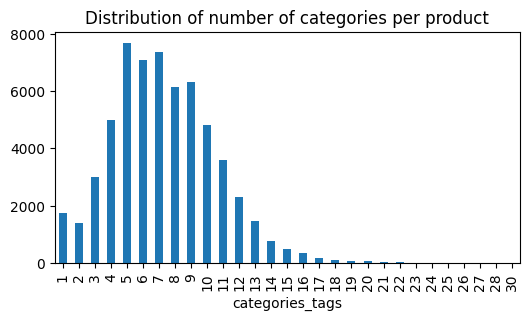

In [9]:
ten_uscans.dropna(subset=['categories_tags']).categories_tags.map(len).value_counts().sort_index().plot.bar(figsize=(6,3));
plt.title('Distribution of number of categories per product');

## Top Categories

- with `en:` prefix
- minimum occurrences

In [10]:
def top_categories(df, min_freq=100):
    """Return the top categories with at least min_freq occurrences."""
    return (
        df.categories_tags
        .explode()
        .value_counts()
        .loc[lambda s: (s >= min_freq) & s.index.str.startswith('en:')]
    )

#top_cats = top_categories(df, min_freq=500)
top_cats = top_categories(ten_uscans, min_freq=100)
top_cats

categories_tags
en:plant-based-foods-and-beverages    24166
en:plant-based-foods                  21459
en:snacks                             12569
en:cereals-and-potatoes                9842
en:sweet-snacks                        9203
                                      ...  
en:crunchy-cereal-clusters              102
en:tunas-in-oil                         102
en:pork-meals                           102
en:uncooked-pressed-cheeses             102
en:getranke                             100
Name: count, Length: 457, dtype: int64

## Finding suitable category with heuristic

- get subset of products with min 10 unique scans (60k)
- count occurrence of categories in subset
- ignore categories with less than 100 products
- get most specific category (lowest frequency) per product
- ignore specific categories with less than 100 occurrences
- count categories and compare with `compare_to_category`
- restrict to countries

## Nutri-Score distribution

- Compute Nutri-Score grade counts for each category.
- Compute diversity (entropy) of Nutri-Scores for each category.
- Select only categories with minimum 100 products

In [11]:
cols = ['categories_tags', 'nutriscore_grade']

#select_cats = lambda x: x['total'] >= 100
select_cats = lambda x: x.index.isin(top_cats.index)

# group by (exploded) categories and Nutri-Score grade
# then sum up by grades and turn into columns.
# only keep categories starting with 'en:'.
grade_counts = (
  #df[cols]
  ten_uscans[cols]
  .dropna(subset=cols[1:])
  .explode(cols[0])
  .dropna(subset=cols[:1])
  .groupby(cols, dropna=False)
  .size()
  .unstack()
  .fillna(0)
  .astype(int)
)

# add total count for scanned products and all products with categories
grade_counts['total'] = grade_counts.sum(axis=1)
grade_counts['all_count'] = grade_counts.index.map(df.dropna(subset=['categories_tags']).categories_tags.explode().value_counts())
grade_counts = grade_counts.sort_values('total', ascending=False)[select_cats]
#grade_counts = grade_counts.sort_values('all_count', ascending=False)[lambda x: x['all_count'] >= 100]
grade_counts

nutriscore_grade,a,b,c,d,e,not-applicable,unknown,total,all_count
categories_tags,,,,,,,,,
en:plant-based-foods-and-beverages,5085,4034,6418,4089,1543,392,2604,24165,491896
en:plant-based-foods,4995,3622,5517,3688,1118,383,2135,21458,428433
en:snacks,237,271,1550,3473,5832,493,713,12569,296190
en:cereals-and-potatoes,2088,1458,3017,2039,442,29,769,9842,147677
en:sweet-snacks,81,133,689,2002,5293,464,541,9203,218501
...,...,...,...,...,...,...,...,...,...
en:uncooked-pressed-cheeses,0,0,2,90,4,0,6,102,6265
en:crunchy-cereal-clusters,6,14,37,25,15,0,5,102,342
en:pork-meals,2,9,65,23,2,0,1,102,2065


### Not Applicable Categories

They need to be removed before further processing as they don't have Nutri-Score grades.
Looking at the fraction of not-application labeling, they are clearly distinguishable from the rest.

In [12]:
def grade_fraction(row, col):
    total = row.values.sum()
    if total == 0:
        return 0
    return row[col] / total

not_appl_count = lambda row: grade_fraction(row, 'not-applicable')
unknown_count = lambda row: grade_fraction(row, 'unknown')

In [13]:
grade_cols = ['a', 'b', 'c', 'd', 'e']
grade_counts['not_appl'] = grade_counts[[*grade_cols, 'not-applicable']].apply(not_appl_count, axis=1)

not_appl = grade_counts[lambda x: x.not_appl > 0.5].sort_values(['not_appl', 'total'], ascending=False)
print(len(not_appl.index))
not_appl

12


nutriscore_grade,a,b,c,d,e,not-applicable,unknown,total,all_count,not_appl
categories_tags,,,,,,,,,,
en:alcoholic-beverages,0,0,0,0,0,342,0,342,34300,1.000000
en:food-additives,0,0,0,0,0,225,0,225,4596,1.000000
en:vinegars,0,0,0,0,0,219,0,219,5619,1.000000
en:beers,0,0,0,0,0,214,0,214,10689,1.000000
en:salts,0,0,0,0,0,182,0,182,3225,1.000000
en:baby-foods,0,0,0,0,0,148,0,148,5659,1.000000
en:sugar-free-chewing-gum,0,0,0,0,0,138,0,138,1736,1.000000
en:spices,0,0,0,0,1,281,0,282,10696,0.996454
en:chewing-gum,0,0,1,0,0,184,0,185,2775,0.994595


# Unknown Status

This is usually the case when nutrition information is missing.
Still need to decide how to handle these cases.

In [14]:
grade_counts['not_known'] = grade_counts[[*grade_cols, 'unknown']].apply(unknown_count, axis=1)
not_known = grade_counts[lambda x: x.not_known > 0.3].sort_values(['not_known', 'total'], ascending=False)
print(len(not_known.index))
not_known

28


nutriscore_grade,a,b,c,d,e,not-applicable,unknown,total,all_count,not_appl,not_known
categories_tags,,,,,,,,,,,
en:instant-coffees,0,5,13,3,2,0,243,266,2502,0.000000,0.913534
en:cocoa-powders,0,2,3,14,9,0,127,155,1405,0.000000,0.819355
en:instant-beverages,0,13,25,37,32,0,485,592,5198,0.000000,0.819257
en:instant-noodles,0,3,29,11,6,0,216,265,2873,0.000000,0.815094
en:beverage-preparations,0,42,30,38,32,6,625,773,6940,0.040541,0.814863
en:flavoured-syrups,0,4,15,10,9,1,150,189,4114,0.025641,0.797872
en:cocoa-and-chocolate-powders,0,2,9,33,29,0,249,322,3098,0.000000,0.773292
en:dried-products-to-be-rehydrated,14,24,137,15,19,7,523,739,11556,0.032407,0.714481
en:herbal-teas,0,101,5,1,2,6,208,323,6970,0.052174,0.656151


### Calculate Nutri-Score Grade Diversity (Entropy)

- Shannon Entropy - good for identifying dominant grades -> this is good!
- Gini - good for identifying category imbalance -> just for getting additional insights

In [15]:
import numpy as np

def shannon_entropy(row):
    values = row.values
    total = values.sum()
    if total == 0:
        return 0
    proportions = values / total
    proportions = proportions[proportions > 0]  # Avoid log(0)
    return -np.sum(proportions * np.log2(proportions))

def gini_impurity(row):
    values = row.values
    total = values.sum()
    if total == 0:
        return 0
    proportions = values / total
    return 1 - np.sum(proportions ** 2)

def grade_order(row):
    # order by most frequent grade and join labels with ','
    if row.not_appl > 0.5:
        return "not-applicable"
    values = row[grade_cols].values
    total = values.sum()
    if total == 0:
        return None
    counts = {k:row[k] for k in row[grade_cols].keys()}
    sorted_grades = sorted(counts.items())
    #sorted_grades = sorted(counts.items(), key=lambda x: (-x[1], x[0]))
    non_zero = [k for k,v in sorted_grades if v/total > 0.10]
    return ','.join(non_zero)

In [16]:
grade_counts['entropy'] = grade_counts[grade_cols].apply(shannon_entropy, axis=1)
grade_counts['gini'] = grade_counts[grade_cols].apply(gini_impurity, axis=1)
grade_counts['label'] = grade_counts.apply(grade_order, axis=1)

# sort
grade_counts = (grade_counts
                .assign(label_len=grade_counts.label.str.len())
                .sort_values(by=['label_len', 'label', 'total'], ascending=[True, True, False])
                .drop(columns=['label_len'])
)
grade_counts

nutriscore_grade,a,b,c,d,e,not-applicable,unknown,total,all_count,not_appl,not_known,entropy,gini,label
categories_tags,,,,,,,,,,,,,,
en:spring-waters,768,13,1,1,0,5,2,790,6152,0.006345,0.002548,0.150088,0.037668,a
en:mineral-waters,673,8,1,1,0,4,1,688,5053,0.005822,0.001462,0.123687,0.028927,a
en:natural-mineral-waters,421,1,0,0,0,1,0,423,2691,0.002364,0.000000,0.024081,0.004728,a
en:cereal-pastas,300,23,3,6,0,0,35,367,6577,0.000000,0.095368,0.564942,0.178273,a
en:durum-wheat-pasta,294,23,3,6,0,0,33,359,6318,0.000000,0.091922,0.572623,0.181283,a
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
en:beers,0,0,0,0,0,214,0,214,10689,1.000000,0.000000,0.000000,0.000000,not-applicable
en:chewing-gum,0,0,1,0,0,184,0,185,2775,0.994595,0.000000,-0.000000,0.000000,not-applicable
en:salts,0,0,0,0,0,182,0,182,3225,1.000000,0.000000,0.000000,0.000000,not-applicable


In [17]:
grade_counts.to_csv('../data/grade_counts.csv', index=True)

In [18]:
grade_counts.label.value_counts()

label
a,b,c             74
c,d,e             57
a,b,c,d           49
d,e               41
c,d               40
b,c               29
b,c,d,e           18
e                 17
a                 16
a,b,c,d,e         15
a,b               13
b,c,d             12
a,c,d             12
not-applicable    12
d                  9
a,c,d,e            8
a,c                6
c                  6
b                  5
c,e                5
b,c,e              3
a,d,e              2
a,d                2
a,b,d              2
a,c,e              1
b,d                1
b,d,e              1
a,b,c,e            1
Name: count, dtype: int64

### Categories with single or two Nutri-Score grades

In [19]:
grade_counts[lambda x: x.label.str.len() == 1].label.value_counts()

label
e    17
a    16
d     9
c     6
b     5
Name: count, dtype: int64

In [20]:
grade_counts[lambda x: x.label.str.len() == 3].label.value_counts()

label
d,e    41
c,d    40
b,c    29
a,b    13
a,c     6
c,e     5
a,d     2
b,d     1
Name: count, dtype: int64

In [21]:
grade_counts[lambda x: x.label == 'a,c']

nutriscore_grade,a,b,c,d,e,not-applicable,unknown,total,all_count,not_appl,not_known,entropy,gini,label
categories_tags,,,,,,,,,,,,,,
en:greek-style-yogurts,114,18,254,3,3,0,20,412,3429,0.000000,0.048544,1.235516,0.493349,"a,c"
en:compotes,261,31,47,2,1,10,6,358,6188,0.028409,0.017241,1.073030,0.390445,"a,c"
en:flours,134,19,40,3,3,2,16,217,7399,0.009950,0.074419,1.355451,0.496604,"a,c"
en:creamy-puddings,35,6,118,14,2,1,8,184,1728,0.005682,0.043716,1.379842,0.497633,"a,c"
en:puddings,72,10,72,2,1,0,9,166,2412,0.000000,0.054217,1.411255,0.575115,"a,c"
en:cereal-flours,108,15,25,1,1,0,12,162,4995,0.000000,0.074074,1.200635,0.443733,"a,c"


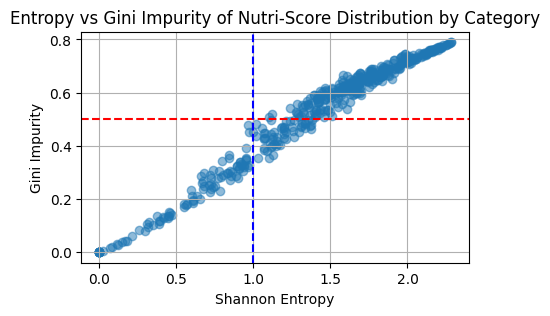

In [22]:
# plot entropy vs Gini impurity
plt.figure(figsize=(5, 3))
plt.scatter(grade_counts['entropy'], grade_counts['gini'], alpha=0.5)
plt.xlabel('Shannon Entropy')
plt.ylabel('Gini Impurity')
plt.title('Entropy vs Gini Impurity of Nutri-Score Distribution by Category')
plt.grid(True)
plt.axhline(0.5, color='red', linestyle='--', label='Gini = 0.5')
plt.axvline(1.0, color='blue', linestyle='--', label='Entropy = 1.0')
plt.savefig('entropy_vs_gini.png', dpi=300, bbox_inches='tight')

In [23]:
one_grade = grade_counts[lambda x: (x.not_appl < 0.5) & (x.label.str.len() == 1)].sort_values('entropy')
print(len(one_grade))
one_grade

53


nutriscore_grade,a,b,c,d,e,not-applicable,unknown,total,all_count,not_appl,not_known,entropy,gini,label
categories_tags,,,,,,,,,,,,,,
en:virgin-olive-oils,0,262,0,0,0,0,25,287,9577,0.000000,0.087108,-0.000000,0.000000,b
en:extra-virgin-olive-oils,0,271,0,0,0,0,34,305,11780,0.000000,0.111475,-0.000000,0.000000,b
en:natural-mineral-waters,421,1,0,0,0,1,0,423,2691,0.002364,0.000000,0.024081,0.004728,a
en:filled-chocolates,0,0,0,1,121,0,3,125,1582,0.000000,0.024000,0.068586,0.016259,e
en:olive-oils,0,321,2,0,1,1,47,372,14207,0.003077,0.126685,0.084344,0.018385,b
en:sweet-cream-butters,0,0,0,2,128,0,2,132,526,0.000000,0.015152,0.114676,0.030296,e
en:mineral-waters,673,8,1,1,0,4,1,688,5053,0.005822,0.001462,0.123687,0.028927,a
en:spring-waters,768,13,1,1,0,5,2,790,6152,0.006345,0.002548,0.150088,0.037668,a
en:chocolates-with-hazelnuts,0,0,1,2,134,0,3,140,1493,0.000000,0.021429,0.172076,0.043050,e


In [24]:
two_grades = grade_counts[lambda x: (x.not_appl < 0.5) & (x.label.isin(['a,b', 'b,c', 'c,d', 'd,e']))].sort_values('entropy')
two_grades

nutriscore_grade,a,b,c,d,e,not-applicable,unknown,total,all_count,not_appl,not_known,entropy,gini,label
categories_tags,,,,,,,,,,,,,,
en:long-grain-rices,0,174,26,1,0,0,19,220,3678,0.000000,0.086364,0.599889,0.233856,"b,c"
en:indica-rices,0,96,20,0,0,0,12,128,2599,0.000000,0.093750,0.663197,0.285375,"b,c"
en:chocolates,2,0,11,237,1383,6,112,1751,28031,0.003661,0.064183,0.667593,0.261638,"d,e"
en:dry-durum-wheat-pasta,89,12,1,1,0,0,8,111,1043,0.000000,0.072072,0.673298,0.239608,"a,b"
en:skyrs,188,33,2,0,0,0,22,245,1124,0.000000,0.089796,0.676560,0.267289,"a,b"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
en:cheeses,203,129,530,1658,256,1,237,3014,77792,0.000360,0.078659,1.699015,0.590815,"c,d"
en:mueslis-with-chocolate,19,8,79,84,5,0,2,197,1068,0.000000,0.010152,1.703363,0.638475,"c,d"
en:chocolate-cereals,34,19,238,221,39,0,11,562,2791,0.000000,0.019573,1.737654,0.642547,"c,d"


In [25]:
three_grades = grade_counts[lambda x: (x.not_appl < 0.5) & (x.label.isin(['a,b,c', 'c,d,e']))].sort_values('entropy')
three_grades

nutriscore_grade,a,b,c,d,e,not-applicable,unknown,total,all_count,not_appl,not_known,entropy,gini,label
categories_tags,,,,,,,,,,,,,,
en:sliced-cheeses,1,0,19,97,16,0,7,140,2200,0.000000,0.050000,1.153762,0.433151,"c,d,e"
en:flavoured-potato-crisps,0,0,53,188,30,0,5,276,2163,0.000000,0.018116,1.177908,0.468240,"c,d,e"
en:frozen-vegetables,127,33,23,0,0,0,5,188,6766,0.000000,0.026596,1.187449,0.470065,"a,b,c"
en:vegetables,587,94,100,12,5,2,77,877,26225,0.002500,0.088000,1.201758,0.429065,"a,b,c"
en:fruit-yogurts,52,45,328,6,14,3,30,478,6599,0.006696,0.063158,1.261378,0.431663,"a,b,c"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
en:crepes-and-galettes,12,9,56,31,55,0,3,166,2633,0.000000,0.018072,2.021638,0.723475,"c,d,e"
en:plant-based-pickles,19,31,128,93,55,2,28,356,9266,0.006098,0.079096,2.040730,0.723550,"c,d,e"
en:pickles,21,33,131,96,58,2,30,371,9734,0.005865,0.081301,2.057055,0.727891,"c,d,e"


In [26]:
grade_counts[lambda x: (x.not_appl < 0.5) & (x.label.str.len() >= 9)].sort_values('entropy')

nutriscore_grade,a,b,c,d,e,not-applicable,unknown,total,all_count,not_appl,not_known,entropy,gini,label
categories_tags,,,,,,,,,,,,,,
en:meal-sauces,64,21,63,27,25,5,16,221,2528,0.024390,0.074074,2.157428,0.753500,"a,b,c,d,e"
en:meat-preparations,27,40,88,68,30,0,13,266,11434,0.000000,0.048872,2.169384,0.756331,"a,b,c,d,e"
en:non-alcoholic-beverages,57,56,162,82,83,33,54,527,5314,0.069767,0.109312,2.196837,0.761147,"a,b,c,d,e"
en:pflanzliche-lebensmittel-und-getranke,34,21,57,43,19,2,8,184,945,0.011364,0.043956,2.203132,0.766944,"a,b,c,d,e"
en:puffed-rice-cakes,22,58,39,30,66,2,19,236,1784,0.009217,0.081197,2.212668,0.770146,"a,b,c,d,e"
en:products-for-specific-diets,48,72,100,37,42,4,13,316,3860,0.013201,0.041667,2.217562,0.769343,"a,b,c,d,e"
en:specific-products,48,72,101,39,42,4,13,319,4458,0.013072,0.041270,2.220523,0.770032,"a,b,c,d,e"
en:dairies,957,1264,2194,2270,1040,63,670,8458,157507,0.008089,0.079809,2.224986,0.772743,"a,b,c,d,e"
en:vegan-products,59,50,83,31,44,0,7,274,1427,0.000000,0.025547,2.247242,0.778830,"a,b,c,d,e"


---

## Plotting

In [27]:
nutricol = {
    'dark_green':  '#008f00',  # C=100, M=25, Y=100
    'lime_green':  '#56bf00',  # C=55,  M=25, Y=100
    'yellow':      '#FFCC00',  # M=20,  Y=100
    # 'orange':      '#FF6600',  # M=60,  Y=100
    'orange':      '#FF7700',
    'red':         '#FF1900',  # M=90,  Y=100
}

fullcol = [*nutricol.values(), 'black', '#ddd', 'grey']

In [28]:
def plot_nutriscore(df):
  fig, ax = plt.subplots(figsize=(6, 10))
  df[:50].plot.barh(stacked=True, ax=ax, color=fullcol)

  ax.invert_yaxis()
  ax.set_ylabel(None)
  ax.xaxis.set_major_formatter(lambda x, pos: f'{int(x):,}')
  #ax.set_xlim(0, 6e5)

  ax.set_axisbelow(True)
  plt.grid(axis='x', linestyle=':', linewidth=0.8)
  plt.legend(title="Nutri-Score")
  plt.title('Top Categories by Nutri-Score (2023)')
  plt.tight_layout()

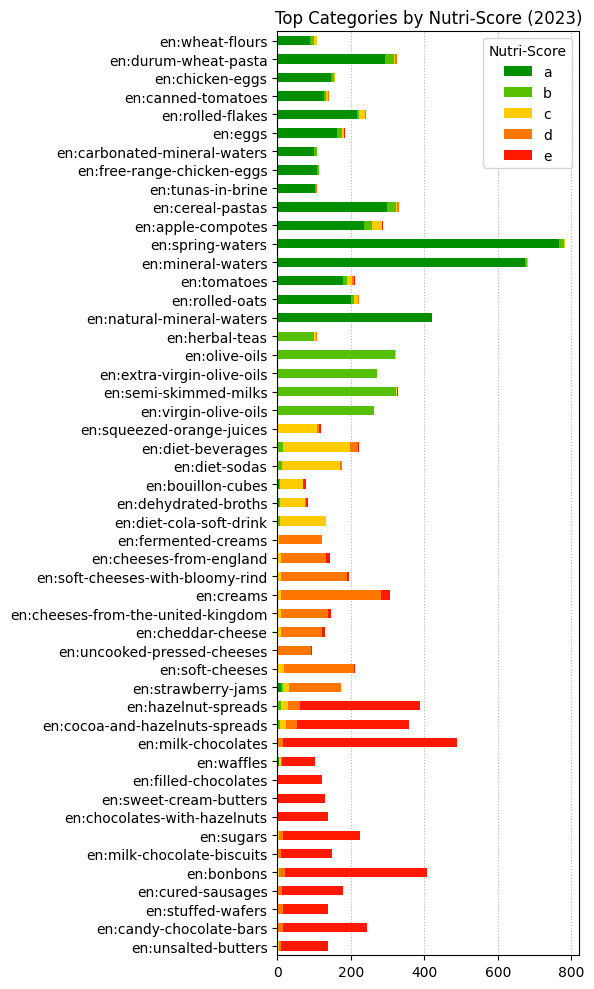

In [29]:
nutri_cols = ['a', 'b', 'c', 'd', 'e']

plot_nutriscore(one_grade.sort_values(['label'])[nutri_cols])

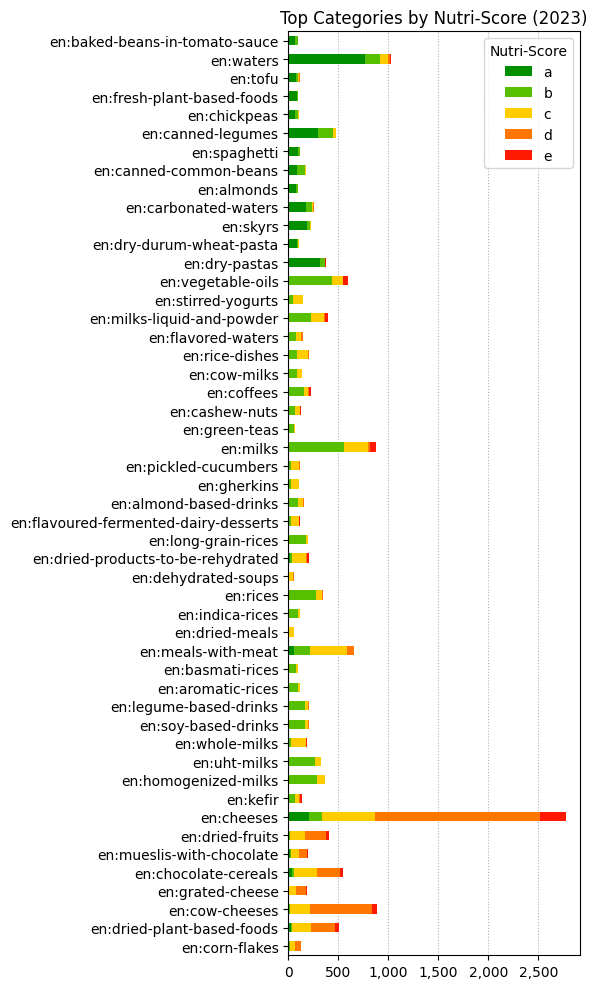

In [30]:
plot_nutriscore(two_grades.sort_values(['label'])[nutri_cols])

In [31]:
grade_counts[['a', 'b', 'c', 'd', 'e']]#.plot.barh(stacked=True, figsize=(6, 8), color=fullcol)

nutriscore_grade,a,b,c,d,e
categories_tags,,,,,
en:spring-waters,768,13,1,1,0
en:mineral-waters,673,8,1,1,0
en:natural-mineral-waters,421,1,0,0,0
en:cereal-pastas,300,23,3,6,0
en:durum-wheat-pasta,294,23,3,6,0
...,...,...,...,...,...
en:beers,0,0,0,0,0
en:chewing-gum,0,0,1,0,0
en:salts,0,0,0,0,0


# Fraction of Products with Categories

In [32]:
def in_index(df, idx):
  return df.loc[lambda df: df.categories_tags.apply(lambda x: any(c in idx for c in x))]

In [33]:
in_index(ten_uscans, grade_counts.index)

,product_name,categories_tags,countries_tags,nutriscore_grade,scans_n,unique_scans_n
code,,,,,,
0009542031695,Excellence 78% Cocoa Dark Chocolate Bar,"[en:snacks, en:sweet-snacks, en:cocoa-and-its-...","[en:france, en:switzerland, en:united-states]",d,16,16
0009800802203,NUTELLA,"[en:plant-based-foods-and-beverages, en:plant-...",[en:united-states],e,11,11
0009800895007,Nutella,"[en:plant-based-foods-and-beverages, en:plant-...",[en:united-states],e,57,55
00014137,Sliced white bread,"[en:plant-based-foods-and-beverages, en:plant-...",[en:united-kingdom],c,21,20
00014885,Peanut Butter,"[en:plant-based-foods-and-beverages, en:plant-...",[en:united-states],c,12,12
...,...,...,...,...,...,...
3240931545332,Girasoli cèpes parmesan,"[en:plant-based-foods-and-beverages, en:plant-...",[en:france],d,32,32
3240931544489,Lustucru gnocchi a poeler pesto & mozzarella 280g,"[en:plant-based-foods-and-beverages, en:plant-...",[en:france],c,10,10
3240931542959,Lustucru tortellini a poeler jambon emmental 300g,"[en:plant-based-foods-and-beverages, en:plant-...",[en:france],c,15,14


In [34]:
onetwo_index = [*not_appl.index, *one_grade.index, *two_grades.index]
all_index = [*not_appl.index, *one_grade.index, *two_grades.index, *three_grades.index]

In [35]:
# top scans: [461, 12, 53, 125, 133, 190, 323]
# all: [2783, 189, 636, 938, 515, 1763, 2278]
indexes = [grade_counts.index, not_appl.index, one_grade.index, two_grades.index, three_grades.index, onetwo_index, all_index]

[len(idx) for idx in indexes]

[457, 12, 53, 123, 131, 188, 319]

In [36]:
[f"{len(idx) / 461:.1%}" for idx in indexes]

['99.1%', '2.6%', '11.5%', '26.7%', '28.4%', '40.8%', '69.2%']

In [37]:
[f"{len(in_index(ten_uscans, idx).index):,}" for idx in indexes]

['58,472', '2,292', '8,199', '28,266', '38,452', '32,315', '50,148']

In [38]:
# top scans: ['97.5%', '3.8%', '13.7%', '47.4%', '64.1%', '54.1%', '83.7%']
# all: ['97.9%', '4.0%', '24.4%', '64.4%', '61.0%', '72.6%', '88.2%']
[f"{len(in_index(ten_uscans, idx).index) / len(ten_uscans.index):.1%}" for idx in indexes]

['97.5%', '3.8%', '13.7%', '47.2%', '64.1%', '53.9%', '83.7%']

In [39]:
hascat = df.dropna(subset='categories_tags')

[f"{len(in_index(hascat, idx).index) / len(hascat.index):.1%}" for idx in indexes]

['92.6%', '5.5%', '8.6%', '37.9%', '50.8%', '46.0%', '71.5%']

In [40]:
rest_index = grade_counts.index.difference(all_index)
grade_counts.loc[rest_index].sort_values('total', ascending=False)

nutriscore_grade,a,b,c,d,e,not-applicable,unknown,total,all_count,not_appl,not_known,entropy,gini,label
categories_tags,,,,,,,,,,,,,,
en:plant-based-foods-and-beverages,5085,4034,6418,4089,1543,392,2604,24165,491896,0.018181,0.109536,2.205613,0.771444,"a,b,c,d"
en:plant-based-foods,4995,3622,5517,3688,1118,383,2135,21458,428433,0.019821,0.101305,2.182479,0.767628,"a,b,c,d"
en:cereals-and-potatoes,2088,1458,3017,2039,442,29,769,9842,147677,0.003196,0.078365,2.138431,0.756208,"a,b,c,d"
en:dairies,957,1264,2194,2270,1040,63,670,8458,157507,0.008089,0.079809,2.224986,0.772743,"a,b,c,d,e"
en:beverages,768,1143,1883,946,1216,417,1362,7735,201701,0.065432,0.186116,2.252904,0.779682,"a,b,c,d,e"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
en:vegetable-broths,4,3,35,1,6,3,58,110,858,0.057692,0.542056,1.374106,0.463973,"c,e"
en:beef,5,16,33,21,18,0,13,106,6479,0.000000,0.122642,2.137310,0.753151,"b,c,d,e"
en:crunchy-cereal-clusters,6,14,37,25,15,0,5,102,342,0.000000,0.049020,2.102364,0.739505,"b,c,d,e"


In [41]:
grade_counts.loc[rest_index].sort_values('total', ascending=False).label.value_counts()

label
a,b,c,d      49
b,c,d,e      18
a,b,c,d,e    15
a,c,d        12
b,c,d        12
a,c,d,e       8
a,c           6
c,e           5
b,c,e         3
a,d,e         2
a,b,d         2
a,d           2
a,b,c,e       1
b,d,e         1
b,d           1
a,c,e         1
Name: count, dtype: int64

In [42]:
# remaining products
missing = ten_uscans.loc[lambda df: ~df.categories_tags.apply(lambda x: any(c in all_index for c in x))].sort_values('unique_scans_n')
missing

,product_name,categories_tags,countries_tags,nutriscore_grade,scans_n,unique_scans_n
code,,,,,,
4006040041801,Klare Gemüsesuppe,"[en:bruhen, en:gemusebruhen, en:pflanzliche-le...",[en:germany],c,11,10
20790271,Salată de vinete,[ro:salata-de-vinete-cu-ceapă],[en:romania],d,10,10
5060614800378,Zero Calorie Golden Syrup,[en:skinny-syrup],"[en:france, en:united-kingdom]",b,10,10
5411188137146,PLANT BASED GUT HEALTH PEACH,[en:plant-based-yogurt],"[en:luxembourg, en:united-kingdom]",b,12,10
8410069013484,Gnocchis,"[en:plant-based-foods-and-beverages, en:plant-...","[en:france, en:spain]",b,10,10
...,...,...,...,...,...,...
8445290615350,sauce tomate cuisinée,"[en:condiments, en:sauces, en:tomato-sauces]",[en:morocco],c,687,595
6111246954461,jibal jben,[en:chees],[en:morocco],d,681,612
5025125000112,White Sourdough Bread,"[en:plant-based-foods-and-beverages, en:plant-...",[en:united-kingdom],b,770,714


In [43]:
missing.categories_tags.explode().value_counts()

categories_tags
en:plant-based-foods-and-beverages    5189
en:plant-based-foods                  4896
en:cereals-and-potatoes               3776
en:cereals-and-their-products         1917
en:breads                             1753
                                      ... 
en:multigrain-chips                      1
en:fresh-bananas                         1
en:coffwe                                1
en:egg-mayo                              1
fr:levure-patissiere                     1
Name: count, Length: 3674, dtype: int64

In [44]:
ten_uscans.loc['5449000147417'].categories_tags

['en:beverages-and-beverages-preparations',
 'en:plant-based-foods-and-beverages',
 'en:beverages',
 'en:plant-based-beverages',
 'en:fruit-based-beverages',
 'en:juices-and-nectars',
 'en:orange-based-beverages']

---